In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector


In [57]:
#open a connection to MySQL Database 
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password="",
    database='rutgers_gym_db'
)

#joins gyms and popular_times tables to get gym name along with busyness data
query = """
    SELECT g.gym_name, p.day_of_week, p.hour, p.hour_24,
            p.is_weekend, p.busyness_pct, p.capacity_label
    FROM popular_times p
    JOIN gyms g ON p.gym_id = g.gym_id
"""

#load query into pandas
df = pd.read_sql(query, conn)

#close the connection
conn.close()

/var/folders/4n/htvq5khx6bxfdhhx24xfmn180000gn/T/ipykernel_46604/2046564002.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


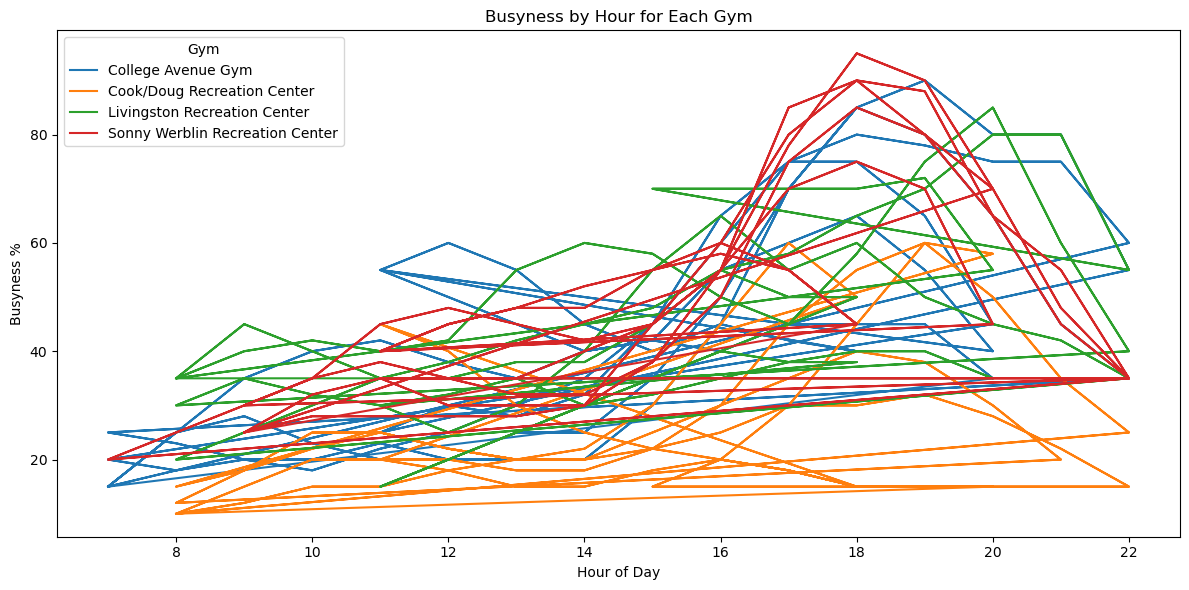

In [58]:
#get list of unique gyms
gyms = df['gym_name'].unique()

#set figure size
plt.figure(figsize=(12, 6))

#loop through each gym and plot its lines
for gym in gyms:

    #data filtering for only rows
    gym_data = df[df['gym_name'] == gym]

    #line plot hour for x and busyness for y
    plt.plot(gym_data['hour_24'], gym_data['busyness_pct'], label=gym)

#title and axis labels
plt.title('Busyness by Hour for Each Gym')
plt.xlabel('Hour of Day')
plt.ylabel('Busyness %')

#legend 
plt.legend(title='Gym')

#adjust the spacing automatically
plt.tight_layout()

#display plot
plt.show()

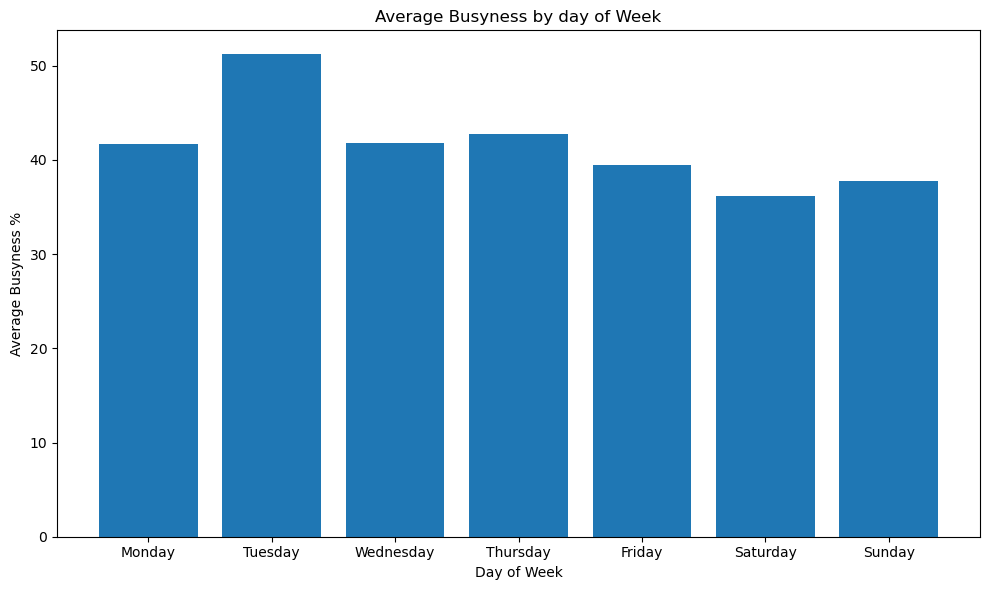

In [59]:
#define correct order of days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

#group data by data and caluclate average busyness per day
avg_by_day = df.groupby('day_of_week')['busyness_pct'].mean()

#reorder the days
avg_by_day = avg_by_day.reindex(day_order)

#set figure size
plt.figure(figsize=(10, 6))

#bar chart with days on x and average busyness on y
plt.bar(avg_by_day.index, avg_by_day.values)

#titles and labels
plt.title('Average Busyness by day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Busyness %')

#adjust spacing
plt.tight_layout()

#show plot
plt.show()

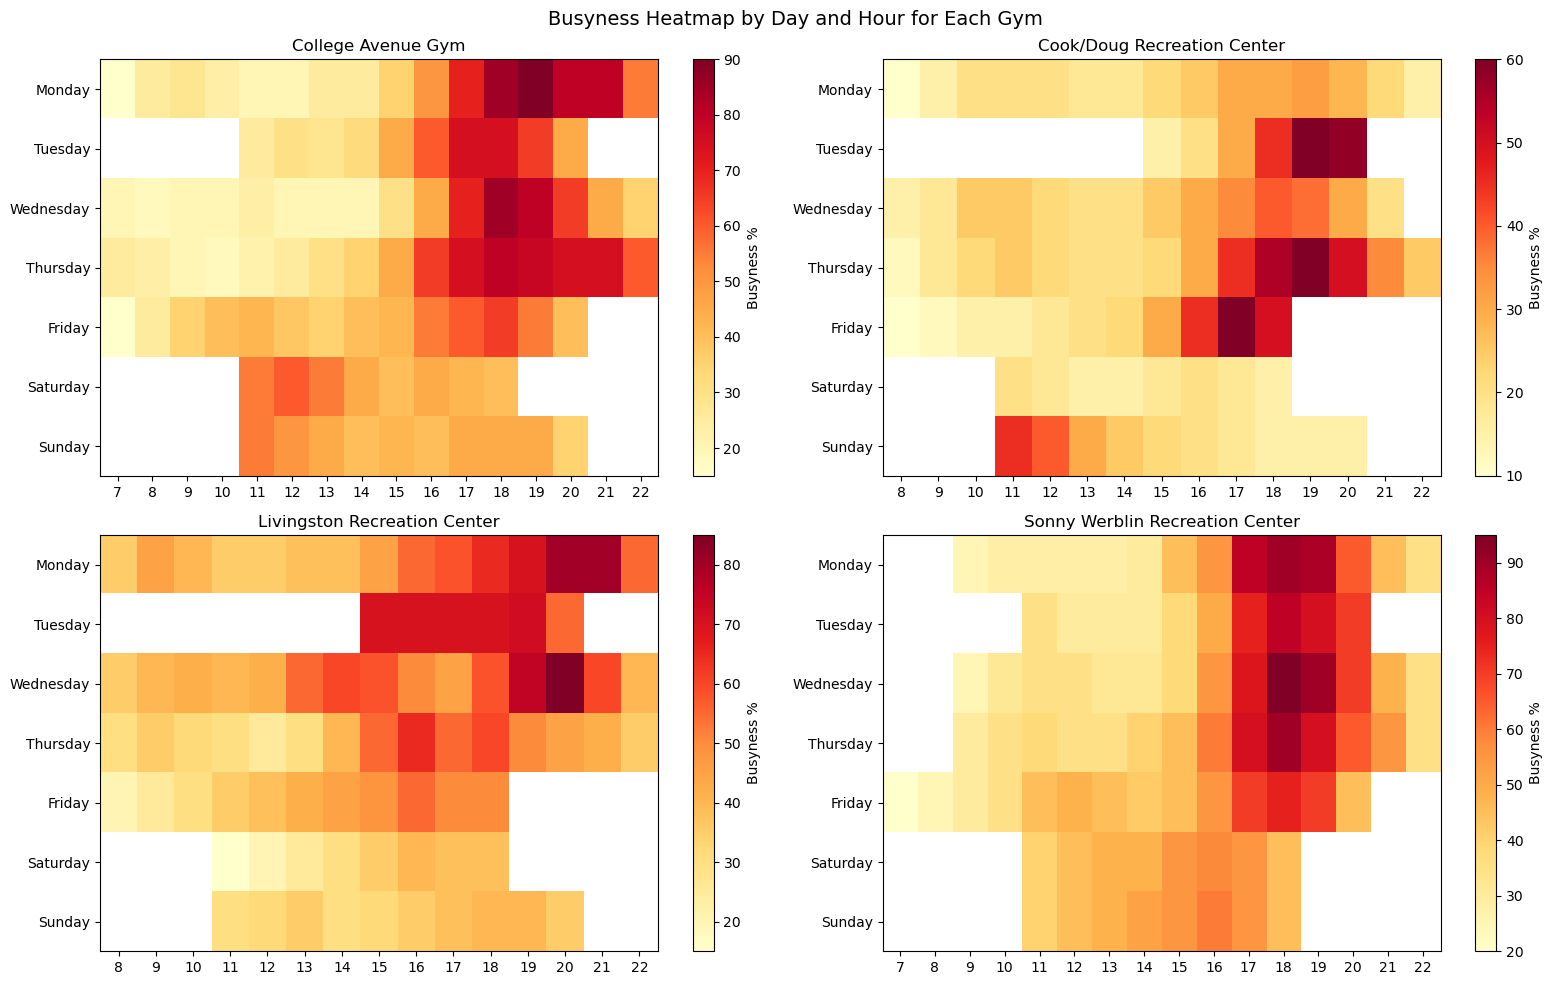

In [60]:
#get grid of subplots for each gym
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

#flatten axes
axes = axes.flatten()

for i, gym in enumerate(gyms):

    #data filtering for gyms only
    gym_data = df[df['gym_name'] == gym]

    #pivot table - rows are days, columns are hours, values are busyness
    pivot = gym_data.pivot_table(
        index='day_of_week',
        columns='hour_24',
        values='busyness_pct'
    )

    #reorder rows to correct day order
    pivot = pivot.reindex(day_order)

    #plot heatmap
    im = axes[i].imshow(pivot, aspect='auto', cmap='YlOrRd')

    #gym titles
    axes[i].set_title(gym)

    #x axis ticks to hours
    axes[i].set_xticks(range(len(pivot.columns)))
    axes[i].set_xticklabels(pivot.columns)
    
    # Set y axis ticks to days
    axes[i].set_yticks(range(len(day_order)))
    axes[i].set_yticklabels(day_order)
    
    # Add a colorbar to show busyness scale
    plt.colorbar(im, ax=axes[i], label='Busyness %')

# Add overall title
fig.suptitle('Busyness Heatmap by Day and Hour for Each Gym', fontsize=14)

# Adjust spacing
plt.tight_layout()

# Display
plt.show()
